<a href="https://colab.research.google.com/github/martinthuriaux/Grokking-Universality/blob/main/00_reproduce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformer_lens

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.6 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=745bd31519d1567d29b8c34565a553d4d50c403a0b35f95703482c9ed24d149c
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator


Setup + prime configuration

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import einops
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ---- Config ----
p = 53              # prime modulus (our choice, != 113)
frac_train = 0.4
seed = 0

Device: cuda


Creating the dataset

In [3]:
def make_dataset(p, seed, frac_train, device):
    # All (a, b) pairs: a_vec runs 0,0,...,0,1,1,...  b_vec runs 0,1,...,p-1,0,1,...
    # Create a vector for a and b of size p^2
    a_vec = einops.repeat(torch.arange(p), "a -> (a b)", b=p)
    b_vec = einops.repeat(torch.arange(p), "b -> (a b)", a=p)
    # A row of length p^2, which is the = token.
    equals = torch.full((p * p,), p)          # the "=" token, index p
    # For each pair, we we find the answer (a + b) mod p
    labels = (a_vec + b_vec) % p

    # inputs: [a, b, =]  shape [p*p, 3]
    inputs = torch.stack([a_vec, b_vec, equals], dim=1).to(device)
    labels = labels.to(device)

    # reproducible train/test split
    torch.manual_seed(seed)
    perm = torch.randperm(p * p)
    n_train = int(frac_train * p * p)
    train_idx, test_idx = perm[:n_train], perm[n_train:]

    return (inputs[train_idx], labels[train_idx],
            inputs[test_idx],  labels[test_idx])

train_x, train_y, test_x, test_y = make_dataset(p, seed, frac_train, device)

print("Train inputs:", train_x.shape, "Train labels:", train_y.shape)
print("Test inputs: ", test_x.shape,  "Test labels: ", test_y.shape)
print("Total pairs: ", p * p)

Train inputs: torch.Size([1123, 3]) Train labels: torch.Size([1123])
Test inputs:  torch.Size([1686, 3]) Test labels:  torch.Size([1686])
Total pairs:  2809


Sanity test for the dataset

In [4]:
# Sanity checks
ex_in, ex_label = train_x[0], train_y[0]
a, b, eq = ex_in.tolist()
print(f"Example input [a, b, =] = {ex_in.tolist()}, label = {ex_label.item()}")
print(f"Check: ({a} + {b}) % {p} = {(a + b) % p}  -> should equal label {ex_label.item()}")

# the '=' token should always be p (the third column)
print("All '=' tokens correct:", (train_x[:, 2] == p).all().item())

# every label in range, every label matches its inputs
labels_ok = ((train_x[:, 0] + train_x[:, 1]) % p == train_y).all().item()
print("All train labels match (a+b)%p:", labels_ok)

Example input [a, b, =] = [3, 52, 53], label = 2
Check: (3 + 52) % 53 = 2  -> should equal label 2
All '=' tokens correct: True
All train labels match (a+b)%p: True


Reproduction of transformer with TransformerLens. This is done to get used to TransformerLens, and also because it makes setting up the architecture a lot easier, allowing for functions such as runwithcache

In [5]:
from transformer_lens import HookedTransformer, HookedTransformerConfig

cfg = HookedTransformerConfig(
    n_layers=1,
    d_model=128,
    d_mlp=512,
    n_heads=4,
    d_head=32,
    n_ctx=3,                 # [a, b, =]
    d_vocab=p + 1,           # numbers 0..p-1 plus the "=" token
    act_fn="relu",
    normalization_type=None, # <-- no LayerNorm (the key grokking simplification)
    seed=seed,
)

model = HookedTransformer(cfg).to(device)
print("Total parameters:", sum(par.numel() for par in model.parameters()))

Moving model to device:  cuda
Total parameters: 212022


Training the model

In [6]:
# cross entropy loss function given the last logit "="
def loss_fn(logits, labels):
    return F.cross_entropy(logits[:, -1, :], labels)

# accuracy function which identifies if the prediction matches the label
def acc_fn(logits, labels):
    preds = logits[:, -1, :].argmax(dim=-1)
    return (preds == labels).float().mean().item()

# set a seat alongside the hyperparameters for the transformer
torch.manual_seed(seed)
model = HookedTransformer(cfg).to(device)
optimizer = torch.optim.AdamW(model.parameters(),
                              lr=1e-3,
                              weight_decay=1.0,
                              betas=(0.9, 0.98))

num_epochs = 30000
train_losses, test_losses = [], []
train_accs,  test_accs    = [], []
epochs_log = []

# train the model
for epoch in tqdm(range(num_epochs)):
    model.train()
    optimizer.zero_grad()
    train_loss = loss_fn(model(train_x), train_y)
    train_loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        model.eval()
        with torch.no_grad():
            tr_logits, te_logits = model(train_x), model(test_x)
            train_losses.append(loss_fn(tr_logits, train_y).item())
            test_losses.append(loss_fn(te_logits, test_y).item())
            train_accs.append(acc_fn(tr_logits, train_y))
            test_accs.append(acc_fn(te_logits, test_y))
            epochs_log.append(epoch)

print(f"Final | train acc {train_accs[-1]:.3f} | test acc {test_accs[-1]:.3f} "
      f"| train loss {train_losses[-1]:.2e} | test loss {test_losses[-1]:.2f}")

Moving model to device:  cuda


100%|██████████| 30000/30000 [02:55<00:00, 170.47it/s]

Final | train acc 1.000 | test acc 1.000 | train loss 3.93e-07 | test loss 0.00


Plotting of results.

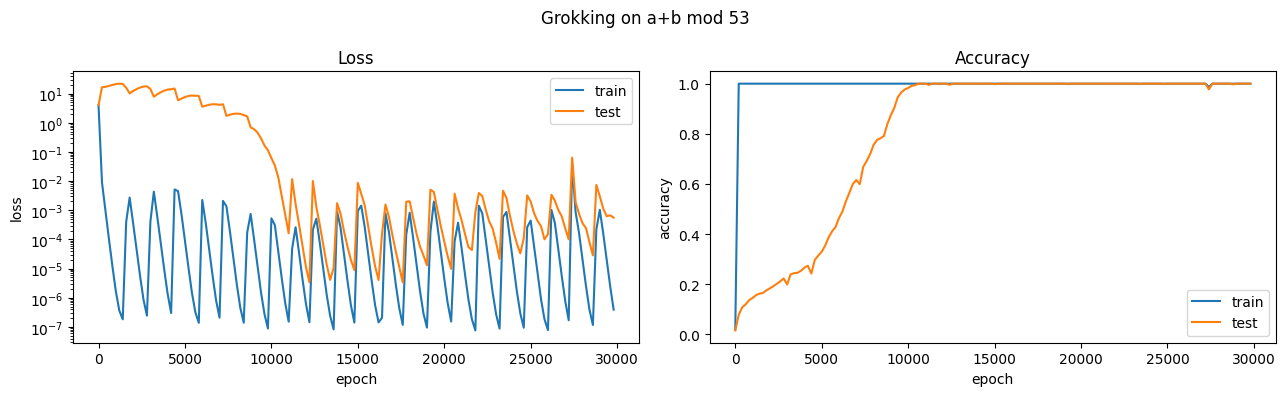

In [7]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# plot the loss (log scale)
ax1.plot(epochs_log, train_losses, label="train")
ax1.plot(epochs_log, test_losses,  label="test")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss")
ax1.set_yscale("log"); ax1.legend(); ax1.set_title("Loss")

# plot the ccuracy
ax2.plot(epochs_log, train_accs, label="train")
ax2.plot(epochs_log, test_accs,  label="test")
ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy")
ax2.legend(); ax2.set_title("Accuracy")

fig.suptitle(f"Grokking on a+b mod {p}")
plt.tight_layout(); plt.show()

In [8]:
# if accuracy > 90%, count it as the grokking speed
def grok_epoch(epochs_log, test_accs, thresh=0.9):
    for e, a in zip(epochs_log, test_accs):
        if a >= thresh:
            return e
    return None

To identify periodicity of the fourier transforms, we do the following.

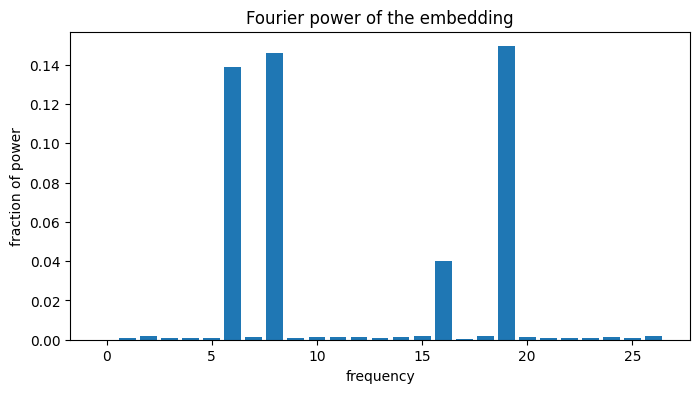

Key frequencies: [6, 8, 19]


In [9]:
# embedding for the NUMBER tokens only (rows 0..p-1; row p is the "=" token)
W_E = model.W_E[:p]                          # shape [p, d_model]

# remove the constant offset so it doesn't dominate the plot (explained below)
W_E = W_E - W_E.mean(dim=0, keepdim=True)

# Fourier-transform DOWN the number axis: each of the 128 columns is a
# function of the number 0..p-1, and we break each into its frequencies
W_E_fft = torch.fft.fft(W_E, dim=0)          # complex, shape [p, d_model]

# power at each frequency = total magnitude across all 128 dimensions
power = (W_E_fft.abs() ** 2).sum(dim=1)      # shape [p]
power = power / power.sum()                  # turn into fractions

# only the first half of frequencies is meaningful (the FFT is mirror-symmetric)
half = p // 2 + 1
plt.figure(figsize=(8,4))
plt.bar(torch.arange(half).cpu(), power[:half].cpu().detach())
plt.xlabel("frequency"); plt.ylabel("fraction of power")
plt.title("Fourier power of the embedding")
plt.show()

# the key frequencies: those carrying an outsized share of the power
freqs = torch.arange(half)
key_freqs = freqs[power[:half].cpu() > 0.05].tolist()   # threshold picks the tall bars
print("Key frequencies:", key_freqs)

In [10]:
torch.save({
    "seed": seed, "p": p, "frac_train": frac_train,
    "state_dict": model.state_dict(),
    "epochs_log": epochs_log,
    "train_losses": train_losses, "test_losses": test_losses,
    "train_accs": train_accs, "test_accs": test_accs,
    "grok_epoch": grok_epoch(epochs_log, test_accs),
    "key_freqs": key_freqs,
}, "run_seed0.pt")
print("Saved.")

Saved.


Now check for MLP neurons single frequency. We first check neuron 0, and then expand to all neurons.

In [11]:
# all p*p pairs [a, b, =], in order, so neuron acts form a clean p x p grid
a_all = einops.repeat(torch.arange(p), "a -> (a b)", b=p)
b_all = einops.repeat(torch.arange(p), "b -> (a b)", a=p)
eq_all = torch.full((p*p,), p)
all_x = torch.stack([a_all, b_all, eq_all], dim=1).to(device)

# run the model and grab the MLP neuron activations at the "=" position
logits, cache = model.run_with_cache(all_x)
neuron_acts = cache["post", 0, "mlp"]      # [p*p, n_ctx, d_mlp]
neuron_acts = neuron_acts[:, -1, :]        # keep the "=" position -> [p*p, d_mlp]
print("Neuron activations:", neuron_acts.shape)   # expect [2809, 512]

Neuron activations: torch.Size([2809, 512])


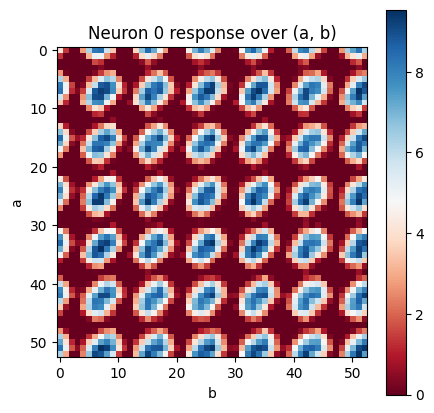

In [12]:
neuron = neuron_acts[:, 0]      # neuron 0's response to all 2809 pairs -> [2809]
grid = neuron.reshape(p, p)     # [53, 53]: grid[a, b] = neuron's response to (a, b)

plt.figure(figsize=(5,5))
plt.imshow(grid.cpu().detach(), cmap="RdBu")
plt.xlabel("b"); plt.ylabel("a"); plt.title("Neuron 0 response over (a, b)")
plt.colorbar(); plt.show()

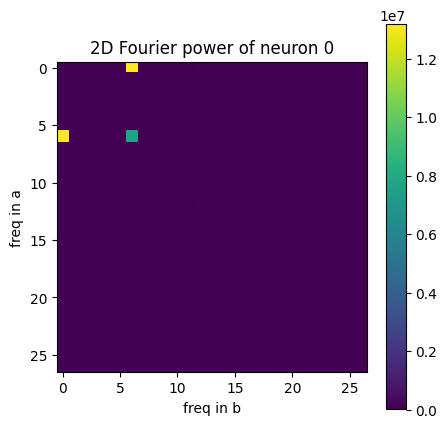

In [13]:
grid = neuron_acts[:, 0].reshape(p, p)
grid = grid - grid.mean()                    # drop the constant offset again

fft2 = torch.fft.fft2(grid)                  # 2D Fourier transform
power2 = fft2.abs() ** 2                      # power at each (freq_a, freq_b)

half = p // 2 + 1
plt.figure(figsize=(5,5))
plt.imshow(power2[:half, :half].cpu().detach(), cmap="viridis")
plt.xlabel("freq in b"); plt.ylabel("freq in a")
plt.title("2D Fourier power of neuron 0")
plt.colorbar(); plt.show()

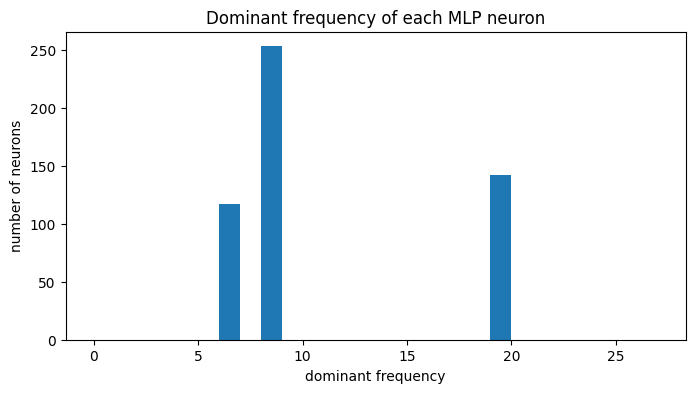

Counter({8: 253, 19: 142, 6: 117})


In [14]:
# 2D-FFT every neuron's response grid at once
acts_grid = neuron_acts.reshape(p, p, -1)          # [53, 53, 512]
acts_grid = acts_grid - acts_grid.mean(dim=(0,1), keepdim=True)
fft2_all = torch.fft.fft2(acts_grid, dim=(0,1))    # [53, 53, 512]
power_all = (fft2_all.abs()**2)                    # power per (freq_a, freq_b) per neuron

# for each neuron, find its dominant frequency
half = p // 2 + 1
# collapse the 2D freq into "which 1D frequency dominates": sum power over rows & cols
freq_power = power_all[:half, :half, :].sum(dim=1) + power_all[:half, :half, :].sum(dim=0)  # [half, 512]
freq_power[0] = 0                                  # ignore the constant (freq 0)
dominant_freq = freq_power.argmax(dim=0)           # [512]: each neuron's top frequency

# histogram: how many neurons belong to each frequency
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.hist(dominant_freq.cpu().numpy(), bins=range(half+1))
plt.xlabel("dominant frequency"); plt.ylabel("number of neurons")
plt.title("Dominant frequency of each MLP neuron")
plt.show()

# print the tally
import collections
print(collections.Counter(dominant_freq.cpu().tolist()))

Proof of trig identity in MLP. Essentially we want to show that the MLP achieves cos(w·a)cos(w·b) − sin(w·a)sin(w·b) = cos(w·(a+b)). When this occurs, theres only actibations on the pairs where freq_a = freq_b

In [15]:
with torch.no_grad():
    logits_all = model(all_x)          # [p*p, n_ctx, d_vocab]
logits_last = logits_all[:, -1, :]     # [p*p, d_vocab] -- scores at the "=" position

A function of a+b wiggles at the same rate in a and b, so its Fourier power lands exactly on the freq_a == freq_b diagonal — at (6,6), (8,8), (19,19) for the key frequencies. Any dependence on a or b alone would put power off that diagonal.

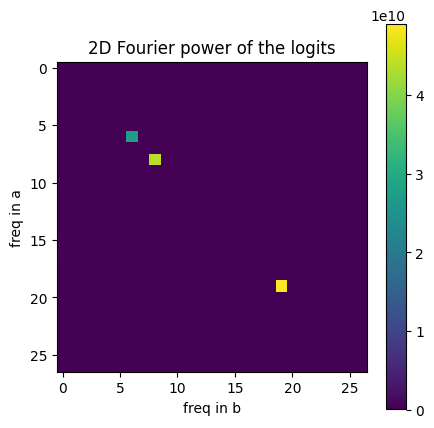

Fraction of logit power on the sum-diagonal (freq_a == freq_b): 0.921


In [16]:
# reshape logits into a grid over (a, b), then 2D-FFT
logits_grid = logits_last.reshape(p, p, -1)                       # [p, p, d_vocab]
logits_grid = logits_grid - logits_grid.mean(dim=(0,1), keepdim=True)
fft_logits = torch.fft.fft2(logits_grid, dim=(0,1))              # [p, p, d_vocab]
power = (fft_logits.abs()**2).sum(dim=-1)                        # [p, p] over (freq_a, freq_b)

half = p // 2 + 1
plt.figure(figsize=(5,5))
plt.imshow(power[:half, :half].cpu().detach(), cmap="viridis")
plt.xlabel("freq in b"); plt.ylabel("freq in a")
plt.title("2D Fourier power of the logits")
plt.colorbar(); plt.show()

# the quantitative result: fraction of power on the freq_a == freq_b diagonal
diag = torch.diagonal(power)                     # power[k, k] for all k
frac_on_diagonal = (diag.sum() / power.sum()).item()
print(f"Fraction of logit power on the sum-diagonal (freq_a == freq_b): {frac_on_diagonal:.3f}")

If the model computes a+b, then any two inputs with the same sum must give the same output. Inputs with the same a+b lie on the same diagonal, so the grid is constant along diagonals.

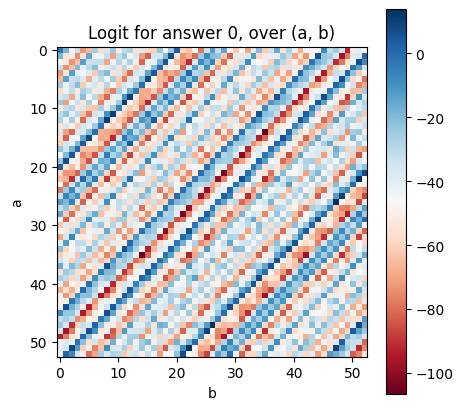

In [18]:
c = 0                                        # look at the logit for answer "0"
grid_c = logits_last[:, c].reshape(p, p)     # [p, p]: score for answer 0 over all (a,b)

plt.figure(figsize=(5,5))
plt.imshow(grid_c.cpu().detach(), cmap="RdBu")
plt.xlabel("b"); plt.ylabel("a")
plt.title("Logit for answer 0, over (a, b)")
plt.colorbar(); plt.show()

In this section, we ablate the key and non-key frequencies and see how this changes the outcome.

In [19]:
def accuracy_from_logit_grid(logit_grid, labels_grid):
    # logit_grid: [p, p, d_vocab] real; labels_grid: [p, p]
    preds = logit_grid.argmax(dim=-1)
    return (preds == labels_grid).float().mean().item()

# ground-truth answer for every (a,b), as a p x p grid
labels_grid = ((torch.arange(p)[:, None] + torch.arange(p)[None, :]) % p).to(device)

# full logits over all pairs, as a grid
with torch.no_grad():
    logits_grid = model(all_x)[:, -1, :].reshape(p, p, -1)   # [p, p, d_vocab]

def ablate_keep_freqs(logits_grid, keep_freqs):
    """Keep ONLY the listed frequencies (and their mirror p-f); zero all others."""
    fft = torch.fft.fft2(logits_grid, dim=(0,1))             # complex [p,p,vocab]
    mask = torch.zeros(p, p, device=logits_grid.device)
    keep = set()
    for f in keep_freqs:
        keep.add(f); keep.add((p - f) % p)                  # include mirror frequency
    keep.add(0)                                             # keep the constant term
    for fa in keep:
        for fb in keep:
            mask[fa, fb] = 1.0
    fft = fft * mask[:, :, None]                            # zero everything else
    return torch.fft.ifft2(fft, dim=(0,1)).real             # back to real logits

# baseline
base_acc = accuracy_from_logit_grid(logits_grid, labels_grid)
print(f"Baseline accuracy (all frequencies):        {base_acc:.3f}")

# keep ONLY the key frequencies
keep_key = ablate_keep_freqs(logits_grid, [6, 8, 19])
print(f"Keep only key freqs [6,8,19]:               {accuracy_from_logit_grid(keep_key, labels_grid):.3f}")

Baseline accuracy (all frequencies):        1.000
Keep only key freqs [6,8,19]:               1.000


In [20]:
def ablate_remove_freqs(logits_grid, remove_freqs):
    """Zero ONLY the listed frequencies (and mirrors); keep everything else."""
    fft = torch.fft.fft2(logits_grid, dim=(0,1))
    for f in remove_freqs:
        for g in {f, (p - f) % p}:
            fft[g, :, :] = 0      # kill this frequency in a
            fft[:, g, :] = 0      # and in b
    return torch.fft.ifft2(fft, dim=(0,1)).real

for f in [6, 8, 19]:
    removed = ablate_remove_freqs(logits_grid, [f])
    acc = accuracy_from_logit_grid(removed, labels_grid)
    print(f"Remove key freq {f:2d}: accuracy -> {acc:.3f}")

Remove key freq  6: accuracy -> 0.721
Remove key freq  8: accuracy -> 0.478
Remove key freq 19: accuracy -> 0.540


In order to identify how frequencies change across different seeds, we want to create a function which is able to identify the key frequencies.

In [21]:
def detect_key_frequencies(model, p, threshold_ratio=20):
    """
    Returns the key frequencies of a grokked model, read from its embedding.
    A frequency is 'key' if its power is > threshold_ratio times the noise floor
    (the median power of the non-key bins).
    """
    W_E = model.W_E[:p]                             # number-token embeddings [p, d_model]
    W_E = W_E - W_E.mean(dim=0, keepdim=True)       # drop the constant offset
    fft = torch.fft.fft(W_E, dim=0)                 # FFT down the number axis
    power = (fft.abs() ** 2).sum(dim=1)             # power per frequency [p]

    half = p // 2 + 1
    power = power[:half].clone()                    # unique half
    power[0] = 0.0                                  # ignore frequency 0 (the constant)

    noise_floor = power[power > 0].median()         # the typical "junk" power level
    freqs = torch.arange(half, device=power.device)
    key_freqs = freqs[power > threshold_ratio * noise_floor].tolist()

    return key_freqs, power

We can do a quick sweep to see which threshold works best. We note that 16 is found to be a "key" frequency in some cases, and this is probably because it has some form of relationship with the 8 frequency.

In [23]:
for r in [5, 10, 20, 50, 100]:
    kf, _ = detect_key_frequencies(model, p, threshold_ratio=r)
    print(f"threshold_ratio={r:3d} -> {kf}")

threshold_ratio=  5 -> [6, 8, 16, 19]
threshold_ratio= 10 -> [6, 8, 16, 19]
threshold_ratio= 20 -> [6, 8, 16, 19]
threshold_ratio= 50 -> [6, 8, 19]
threshold_ratio=100 -> [6, 8, 19]
